In [57]:
import pandas as pd

In [58]:
df = pd.read_csv("dataset_sig_st.csv")

In [59]:
df.columns

Index(['D1_daily_screen', 'age_class', 'A2_gender', 'B1_residence',
       'income_class', 'weight_class', 'D2_weekend_screen', 'D4_content',
       'D5_parents_screen_time', 'D6_ai_daily', 'E5_bedtime', 'E6_wake_time',
       'F1_academic_satisfaction', 'F3_learning_interest',
       'F4_interest_reduced', 'G1_mood_swings', 'G2_anxious_without_device',
       'H1_mobile_while_eating', 'H2_appetite_change', 'BMI_class',
       'D4_content_grouped'],
      dtype='str')

In [60]:

# Check target variable distribution
print("Target variable: D1_daily_screen")
print(df['D1_daily_screen'].value_counts())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())


Target variable: D1_daily_screen
D1_daily_screen
1-3 hours            137
3-5 hours            125
Less than 1 hour     112
More than 5 hours     78
Name: count, dtype: int64

Shape: (452, 21)

Missing values:
 0


## Multinomial Logistic Regression — Target: `D1_daily_screen`

In [61]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [62]:
#  1. Prepare features and target
target = 'D1_daily_screen'
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

# Encode every categorical column with a fresh LabelEncoder
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y.astype(str))
class_names = le_target.classes_

print("Classes:", class_names)
print("Encoded labels:", np.unique(y_enc))


Classes: ['1-3 hours' '3-5 hours' 'Less than 1 hour' 'More than 5 hours']
Encoded labels: [0 1 2 3]


In [63]:

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 361  |  Test size: 91


In [64]:

# 3. Fit Multinomial Logistic Regression
mlr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_test)

# 4. Evaluation 
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.4725 (47.25%)

Classification Report:
                   precision    recall  f1-score   support

        1-3 hours       0.47      0.54      0.50        28
        3-5 hours       0.45      0.56      0.50        25
 Less than 1 hour       0.56      0.45      0.50        22
More than 5 hours       0.40      0.25      0.31        16

         accuracy                           0.47        91
        macro avg       0.47      0.45      0.45        91
     weighted avg       0.47      0.47      0.47        91



### Odds Ratios (per class vs. reference)

In [65]:

# Odds Ratios 
# OR = exp(coefficient); OR > 1 → increases odds of that class, < 1 → decreases
odds_ratio_df = pd.DataFrame(
    np.exp(mlr.coef_),
    index=class_names,
    columns=features
).T

print("Odds Ratios per class (rows=features, columns=D1_daily_screen classes):\n")
print(odds_ratio_df.round(4).to_string())


Odds Ratios per class (rows=features, columns=D1_daily_screen classes):

                           1-3 hours  3-5 hours  Less than 1 hour  More than 5 hours
age_class                     0.5692     1.2689            0.6716             2.0617
A2_gender                     0.8680     1.9618            0.5153             1.1396
B1_residence                  0.5348     1.2299            0.9136             1.6640
income_class                  0.7464     0.8858            1.8427             0.8207
weight_class                  1.1611     0.6738            1.2226             1.0454
D2_weekend_screen             1.4470     0.1645           21.9253             0.1916
D4_content                    0.9293     1.0591            1.0211             0.9950
D5_parents_screen_time        1.1819     0.9512            1.9316             0.4605
D6_ai_daily                   0.8584     1.1916            1.0171             0.9612
E5_bedtime                    1.0049     0.9176            1.6311            

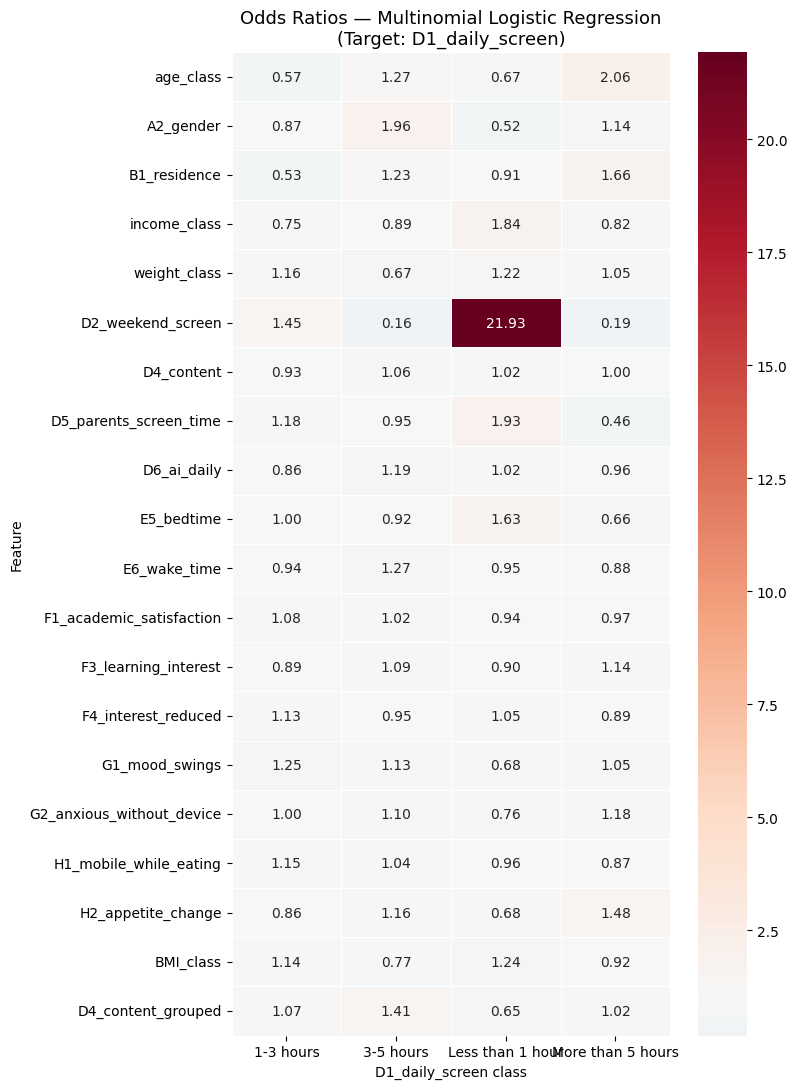

In [66]:

# Odds Ratio Heatmap 
import seaborn as sns

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 2), len(features) * 0.45 + 2))
sns.heatmap(
    odds_ratio_df,
    annot=True, fmt=".2f",
    center=1.0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Odds Ratios — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
ax.set_xlabel("D1_daily_screen class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


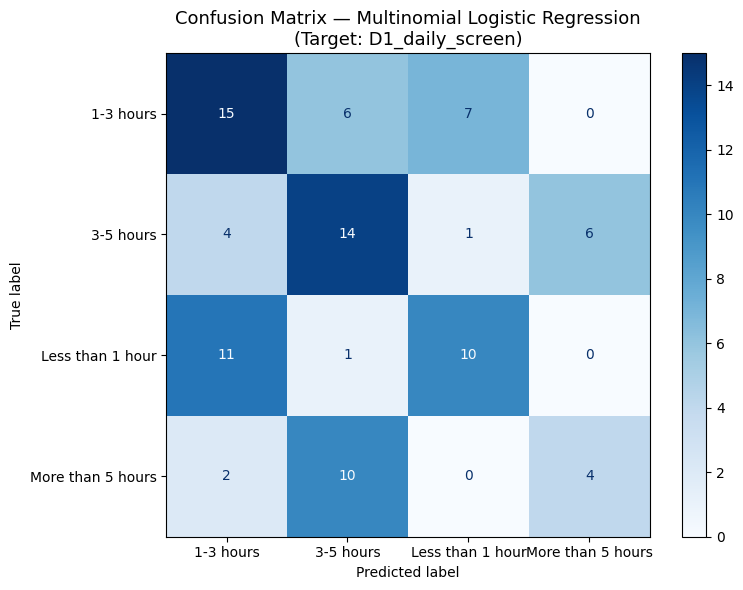

In [67]:

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
plt.tight_layout()
plt.show()


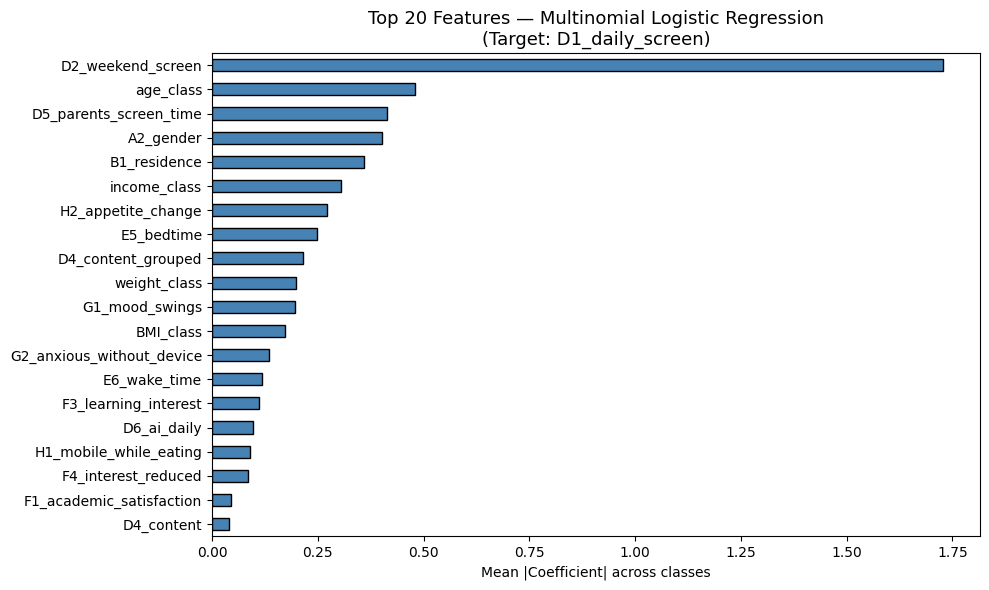


Top 15 features by mean absolute coefficient:
                           mean_abs
D2_weekend_screen          1.728562
age_class                  0.480837
D5_parents_screen_time     0.412747
A2_gender                  0.402261
B1_residence               0.358091
income_class               0.305619
H2_appetite_change         0.271631
E5_bedtime                 0.247061
D4_content_grouped         0.214063
weight_class               0.197409
G1_mood_swings             0.196305
BMI_class                  0.171398
G2_anxious_without_device  0.135215
E6_wake_time               0.117881
F3_learning_interest       0.110585
D6_ai_daily                0.096138
H1_mobile_while_eating     0.089333
F4_interest_reduced        0.085842
F1_academic_satisfaction   0.045751
D4_content                 0.039192


In [68]:

# 6. Feature Importance (Coefficients)
coef_df = pd.DataFrame(
    mlr.coef_,
    index=class_names,
    columns=features
).T

# Mean absolute coefficient across classes → overall importance
coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values('mean_abs', ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted['mean_abs'].head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title(f"Top {top_n} Features — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 15 features by mean absolute coefficient:")
print(coef_df_sorted[['mean_abs']].head(top_n).to_string())
